In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
df = pd.read_csv('../datasets/raw/dataset.csv', encoding='ISO-8859-1')
df.drop(columns=['RESUMEN_SENTENCIA'], inplace=True)

In [55]:
#Configuracion visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [56]:
#Primeras vistas
df.head()

,FEC_INGRESO,PROCEDENCIA,CDES_TIPOPROCESO,SALA_ORIGEN,TIPO_DEMANDANTE,TIPO_DEMANDADO,SALA,FEC_VISTA,MATERIA,SUB_MATERIA,ESPECIFICA,PUB_PAGWEB,PUB_PERUANO,TIPO_RESOLUCION,FALLO,FEC_DEVPJ,FEC_DEVPJ_1,DEPARTAMENTO,PROVINCIA,DISTRITO
0,19920101,LIMA,HÁBEAS CORPUS,--,NATURAL,JURIDICA,--,--,--,--,--,19970607,--,Sentencia,--,--,20260409,LIMA,LIMA,LIMA
1,19920101,LIMA,HÁBEAS CORPUS,--,NATURAL,JURIDICA,--,--,--,--,--,19980924,--,Sentencia,--,--,20260409,LIMA,LIMA,LIMA
2,19920101,LIMA,ACCION DE AMPARO,--,NATURAL,JURIDICA,--,--,--,--,--,19990513,--,Sentencia,--,--,20260409,LIMA,LIMA,LIMA
3,19920101,LIMA,ACCION DE AMPARO,--,NATURAL,JURIDICA,--,--,--,--,--,20010911,--,Sentencia,--,--,20260409,LIMA,LIMA,LIMA
4,19920101,LIMA,HÁBEAS CORPUS,--,NATURAL,JURIDICA,--,--,--,--,--,19990722,--,Sentencia,--,--,20260409,LIMA,LIMA,LIMA


In [57]:
df.shape

(149387, 20)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149387 entries, 0 to 149386
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   FEC_INGRESO       149387 non-null  int64 
 1   PROCEDENCIA       149387 non-null  object
 2   CDES_TIPOPROCESO  149387 non-null  object
 3   SALA_ORIGEN       149387 non-null  object
 4   TIPO_DEMANDANTE   149387 non-null  object
 5   TIPO_DEMANDADO    149387 non-null  object
 6   SALA              149387 non-null  object
 7   FEC_VISTA         149387 non-null  object
 8   MATERIA           149387 non-null  object
 9   SUB_MATERIA       149387 non-null  object
 10  ESPECIFICA        149387 non-null  object
 11  PUB_PAGWEB        149387 non-null  int64 
 12  PUB_PERUANO       149387 non-null  object
 13  TIPO_RESOLUCION   149387 non-null  object
 14  FALLO             149387 non-null  object
 15  FEC_DEVPJ         149387 non-null  object
 16  FEC_DEVPJ_1       149387 non-null  int

In [59]:
#cantidad de nulos
df.isnull().sum()

FEC_INGRESO         0
PROCEDENCIA         0
CDES_TIPOPROCESO    0
SALA_ORIGEN         0
TIPO_DEMANDANTE     0
TIPO_DEMANDADO      0
SALA                0
FEC_VISTA           0
MATERIA             0
SUB_MATERIA         0
ESPECIFICA          0
PUB_PAGWEB          0
PUB_PERUANO         0
TIPO_RESOLUCION     0
FALLO               0
FEC_DEVPJ           0
FEC_DEVPJ_1         0
DEPARTAMENTO        0
PROVINCIA           0
DISTRITO            0
dtype: int64

In [60]:
# Limpieza de fechas (Las fechas están como enteros tipo 19920101 o '--')
df['FEC_INGRESO_STR'] = df['FEC_INGRESO'].astype(str).replace('--', np.nan)
df['YEAR_INGRESO'] = pd.to_numeric(df['FEC_INGRESO_STR'].str[:4], errors='coerce')

df['PUB_PAGWEB_STR'] = df['PUB_PAGWEB'].astype(str).replace('--', np.nan)
df['YEAR_PAGWEB'] = pd.to_numeric(df['PUB_PAGWEB_STR'].str[:4], errors='coerce')

In [61]:
#Calcular variable cuantitativa: Tiempo de Resolución (en años)
df['TIEMPO_RESOLUCION_AÑOS'] = df['YEAR_PAGWEB'] - df['YEAR_INGRESO']

### GRAFICOS

#### Evolucion Historica de la carga procesal

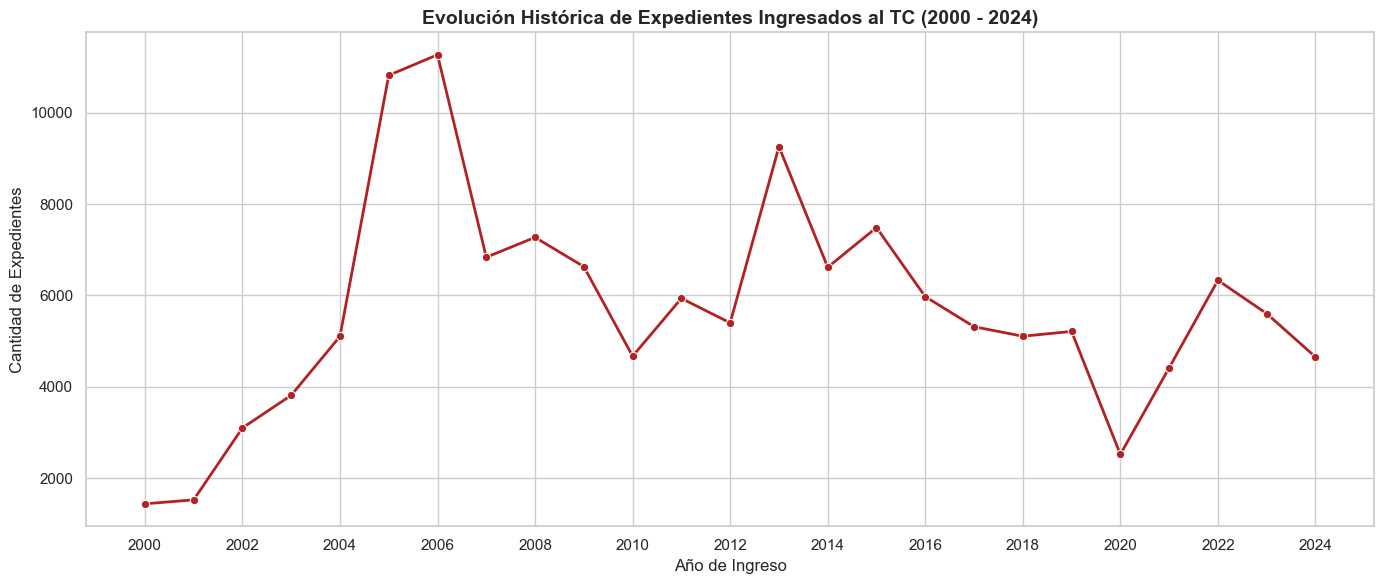

In [ ]:
plt.figure(figsize=(14, 6))
casos_por_anio = df['YEAR_INGRESO'].value_counts().sort_index()
sns.lineplot(x=casos_por_anio.loc[2000:2024].index, y=casos_por_anio.loc[2000:2024].values, marker='o', color='#b22222', linewidth=2)
plt.title('Evolución Histórica de Expedientes Ingresados al TC (2000 - 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Año de Ingreso')
plt.ylabel('Cantidad de Expedientes')
plt.xticks(np.arange(2000, 2025, 2))
plt.tight_layout()
plt.savefig('grafico_evolucion.png')
plt.show()

#### Cantidad de procesos segun sus tipos

C:\Users\bruno\AppData\Local\Temp\ipykernel_29128\1190605766.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_procesos.index, x=top_procesos.values, palette='Blues_r')


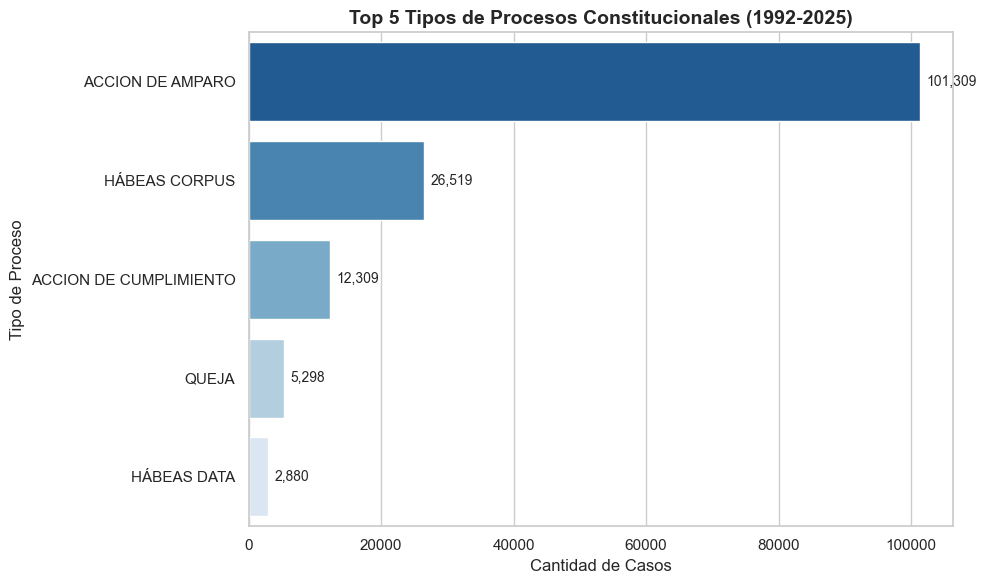

In [ ]:
plt.figure(figsize=(10, 6))
top_procesos = df['CDES_TIPOPROCESO'].value_counts().head(5)
sns.barplot(y=top_procesos.index, x=top_procesos.values, palette='Blues_r')
plt.title('Top 5 Tipos de Procesos Constitucionales (1992-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Casos')
plt.ylabel('Tipo de Proceso')
for i, v in enumerate(top_procesos.values):
    plt.text(v + 1000, i, f"{v:,}", va='center', fontsize=10)
plt.tight_layout()
plt.savefig('grafico_procesos.png')
plt.show()

#### Distribucion de procesos por departamentos

C:\Users\bruno\AppData\Local\Temp\ipykernel_29128\899324729.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_deptos.index, y=top_deptos.values, palette='viridis')


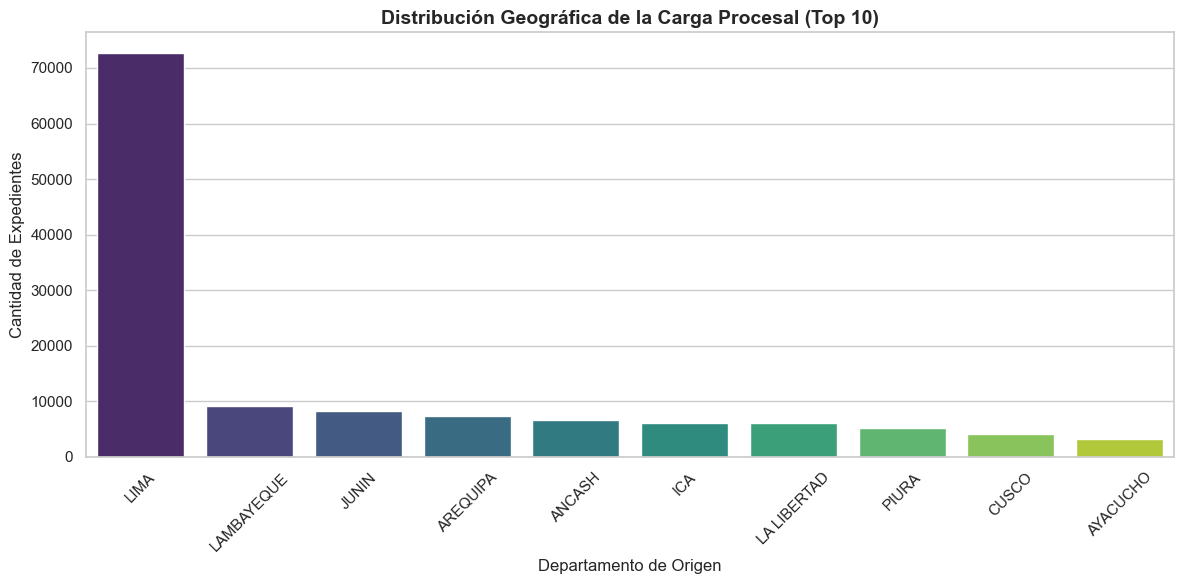

In [48]:
plt.figure(figsize=(12, 6))
top_deptos = df['DEPARTAMENTO'].value_counts().head(10)
sns.barplot(x=top_deptos.index, y=top_deptos.values, palette='viridis')
plt.title('Distribución Geográfica de la Carga Procesal (Top 10)', fontsize=14, fontweight='bold')
plt.xlabel('Departamento de Origen')
plt.ylabel('Cantidad de Expedientes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('grafico_geografico.png')
plt.show()

#### Evolucion del tiempo promedio por resolucion

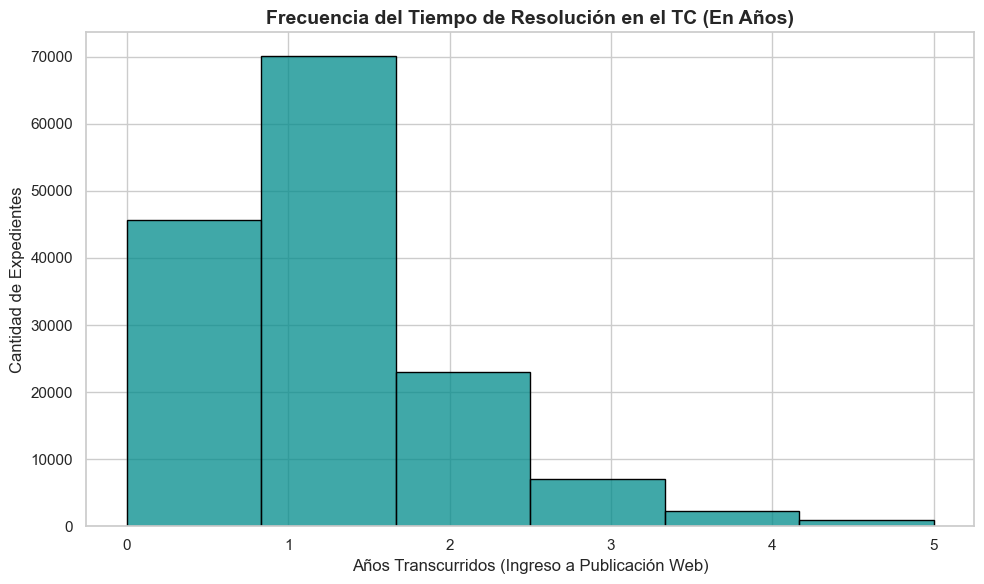

In [49]:
plt.figure(figsize=(10, 6))
# Filtramos datos atípicos extremos para ver la campana clara (resoluciones entre 0 y 5 años)
tiempos_validos = df[(df['TIEMPO_RESOLUCION_AÑOS'] >= 0) & (df['TIEMPO_RESOLUCION_AÑOS'] <= 5)]
sns.histplot(tiempos_validos['TIEMPO_RESOLUCION_AÑOS'], bins=6, kde=False, color='darkcyan', edgecolor='black')
plt.title('Frecuencia del Tiempo de Resolución en el TC (En Años)', fontsize=14, fontweight='bold')
plt.xlabel('Años Transcurridos (Ingreso a Publicación Web)')
plt.ylabel('Cantidad de Expedientes')
plt.tight_layout()
plt.savefig('grafico_tiempo_resolucion.png')
plt.show()

#### Proceso vs Fallo

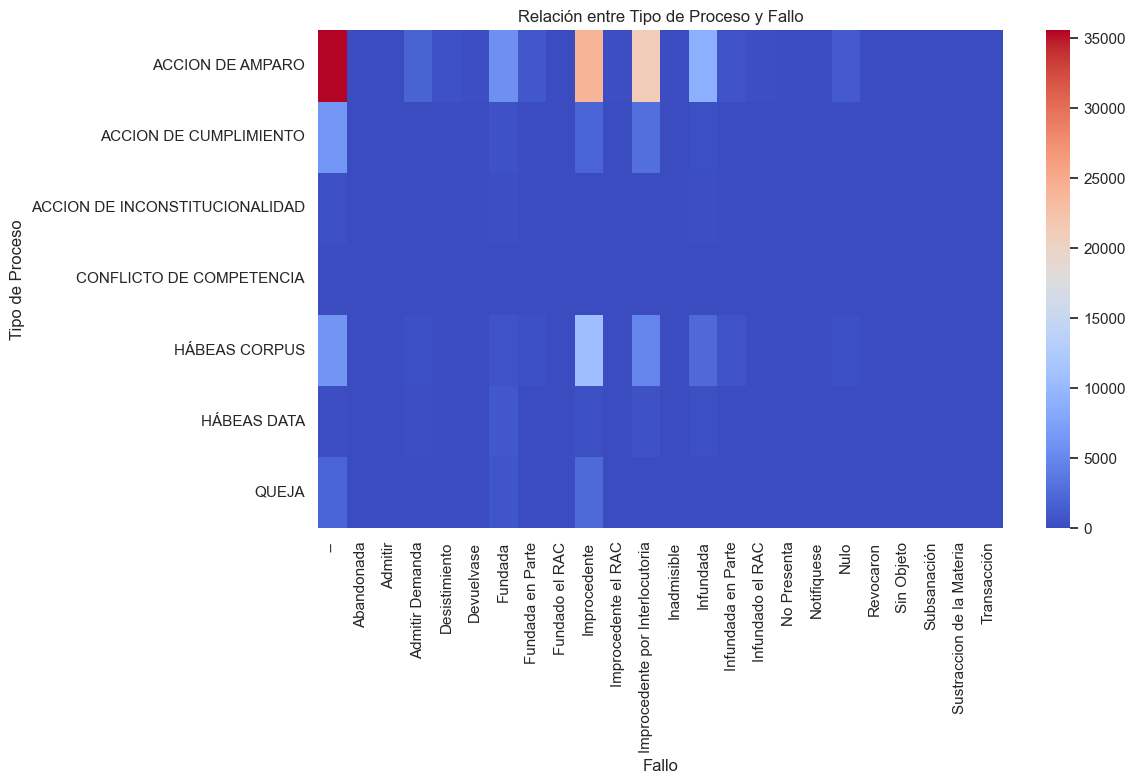

In [63]:
tabla = pd.crosstab(df['CDES_TIPOPROCESO'], df['FALLO'])

plt.figure(figsize=(12, 8))
sns.heatmap(tabla, cmap='coolwarm', annot=False)

plt.title('Relación entre Tipo de Proceso y Fallo')
plt.xlabel('Fallo')
plt.ylabel('Tipo de Proceso')
plt.tight_layout()
plt.show()

#### Evolucion del tiempo promedio por resolucion

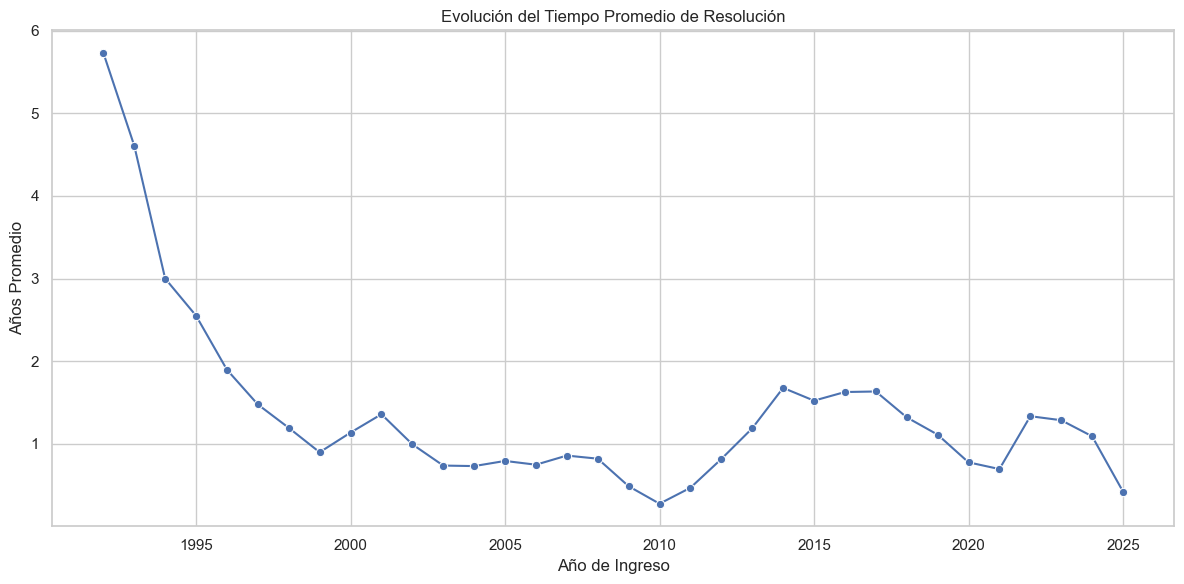

In [64]:
promedio_tiempo = df.groupby('YEAR_INGRESO')['TIEMPO_RESOLUCION_AÑOS'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=promedio_tiempo.index, y=promedio_tiempo.values, marker='o')

plt.title('Evolución del Tiempo Promedio de Resolución')
plt.xlabel('Año de Ingreso')
plt.ylabel('Años Promedio')
plt.tight_layout()
plt.show()

#### Tiempo promedio de Resolucion segun la Materia

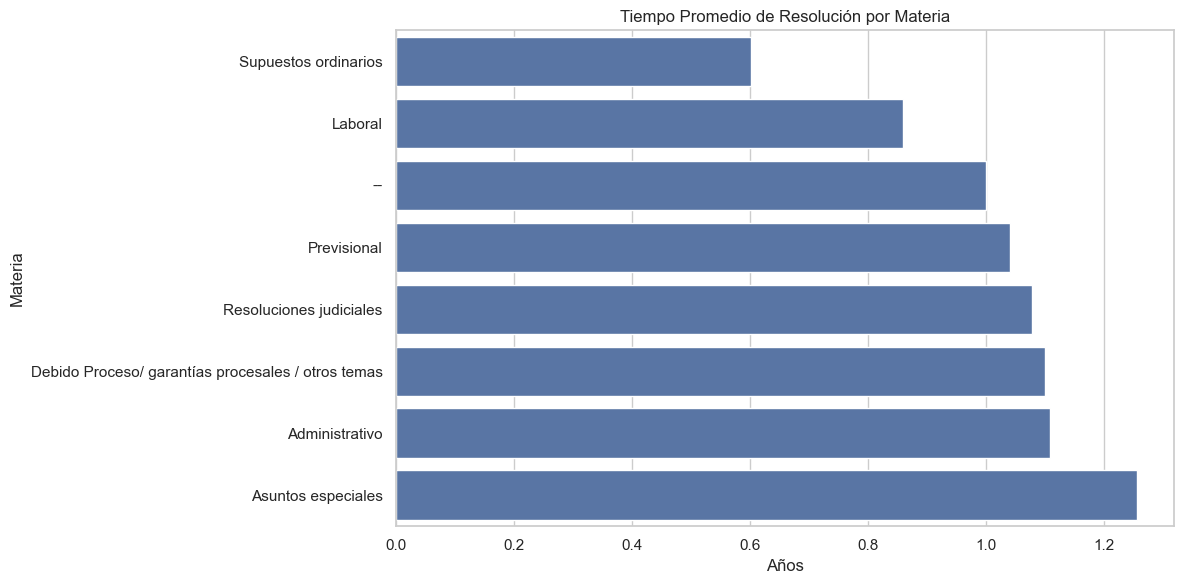

In [65]:
top_materias = df['MATERIA'].value_counts().head(8).index
df_mat = df[df['MATERIA'].isin(top_materias)]

tiempo_materia = df_mat.groupby('MATERIA')['TIEMPO_RESOLUCION_AÑOS'].mean().sort_values()

plt.figure(figsize=(12, 6))
sns.barplot(x=tiempo_materia.values, y=tiempo_materia.index)

plt.title('Tiempo Promedio de Resolución por Materia')
plt.xlabel('Años')
plt.ylabel('Materia')
plt.tight_layout()
plt.show()

#### Cantidad vs Tiempo (Eficiencia)

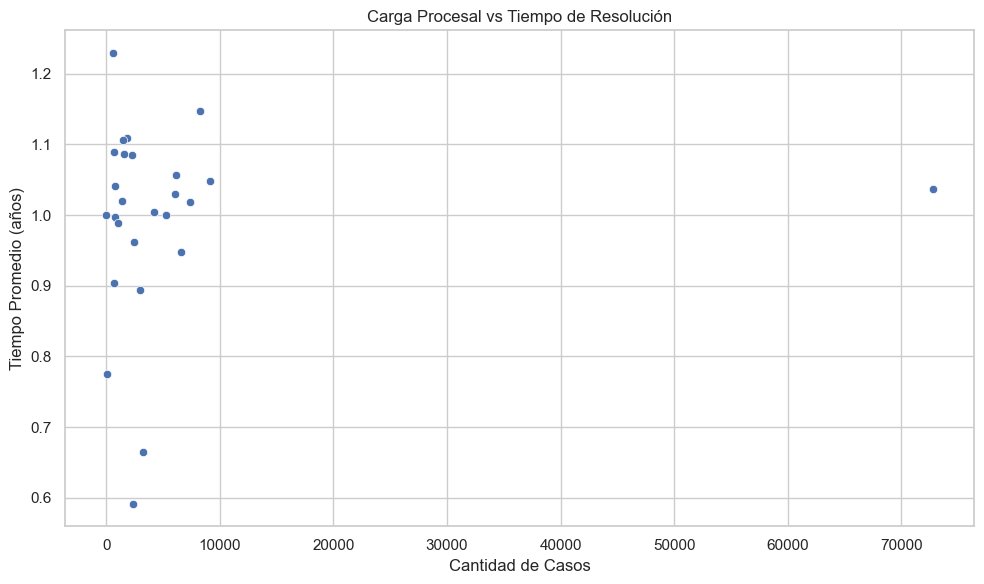

In [67]:
agrupado = df.groupby('DEPARTAMENTO').agg({
    'TIEMPO_RESOLUCION_AÑOS': 'mean',
    'FEC_INGRESO': 'count'
}).rename(columns={'FEC_INGRESO': 'CANTIDAD'})

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=agrupado,
    x='CANTIDAD',
    y='TIEMPO_RESOLUCION_AÑOS'
)

plt.title('Carga Procesal vs Tiempo de Resolución')
plt.xlabel('Cantidad de Casos')
plt.ylabel('Tiempo Promedio (años)')
plt.tight_layout()
plt.show()